In [3]:
from pathlib import Path
import pandas as pd
import json
import pickle
import warnings
import shutil
import re, glob,os
import hdf5storage
from tqdm import tqdm
from copy import deepcopy
import numpy as np

import importlib
import utils.functions as func
importlib.reload(func)
from utils.functions import *
import utils.pre_processing as pre_processing
importlib.reload(pre_processing)
from utils.pre_processing import *


import tifffile
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# from hcipy import Field, make_pupil_grid, get_strehl_from_focal, radial_profile
from applefy_extensions.contrast_curves import ContrastFast
from applefy.statistics import TTest, gaussian_sigma_2_fpf, fpf_2_gaussian_sigma
from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.utils.file_handling import save_as_fits
from applefy.utils.contrast_grid import compute_contrast_from_grid

from fours.utils.data_handling import read_fours_root_dir
from fours.utils.setups import contrast_grid_setup_1
from fours.detection_limits.applefy_wrapper import CADIDataReductionGPU, PCADataReductionGPU
from fours.detection_limits.applefy_wrapper import FourSDataReduction
from fours.models.psf_subtraction import FourS

# Load the original tiff

## Check centering

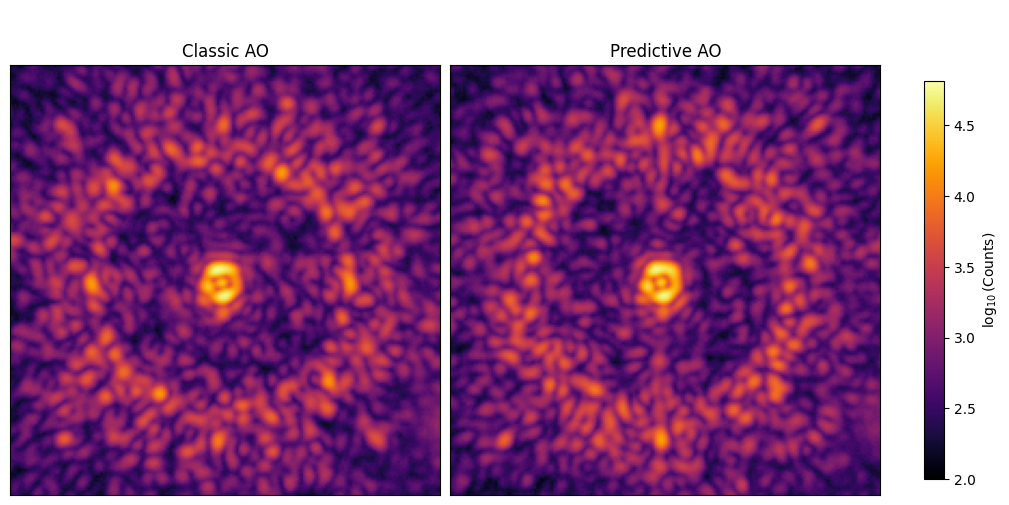

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import tifffile as tiff
import glob

# ------------------------
# Load stacks
# ------------------------
img_file = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/int_0.5ro_10ws_coro_202'
sci_img_int = tiff.imread(glob.glob(f"{img_file}*.tif"), key=range(6667))

img_file = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/pred_0.5ro_10ws_coro_'
sci_img_pred = tiff.imread(glob.glob(f"{img_file}*.tif"), key=range(6667))

# ------------------------
# Avoid log(0)
# ------------------------
eps = 1e-9
int_log = np.log10(np.maximum(sci_img_int[::100,:,:], eps))
pred_log = np.log10(np.maximum(sci_img_pred[::100,:,:], eps))

# Shared color scale
vmin = 2
vmax = np.log10(65535)

# ------------------------
# Figure
# ------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

im0 = ax[0].imshow(int_log[0], origin="lower",
                   cmap="inferno", vmin=vmin, vmax=vmax)
im1 = ax[1].imshow(pred_log[0], origin="lower",
                   cmap="inferno", vmin=vmin, vmax=vmax)

ax[0].set_title("Classic AO")
ax[1].set_title("Predictive AO")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

cbar = fig.colorbar(im1, ax=ax, shrink=0.9)
cbar.set_label(r'$\log_{10}(\mathrm{Counts})$')

frame_text = fig.suptitle("Frame 0")

# ------------------------
# Animation
# ------------------------
def update(i):
    im0.set_data(int_log[i])
    im1.set_data(pred_log[i])
    frame_text.set_text(f"Frame {i}")
    return im0, im1, frame_text

ani = FuncAnimation(
    fig,
    update,
    frames=len(int_log),
    interval=30,
    blit=True,
)

# Save
ani.save("coronagraph_comparison.gif",
         writer=PillowWriter(fps=30))

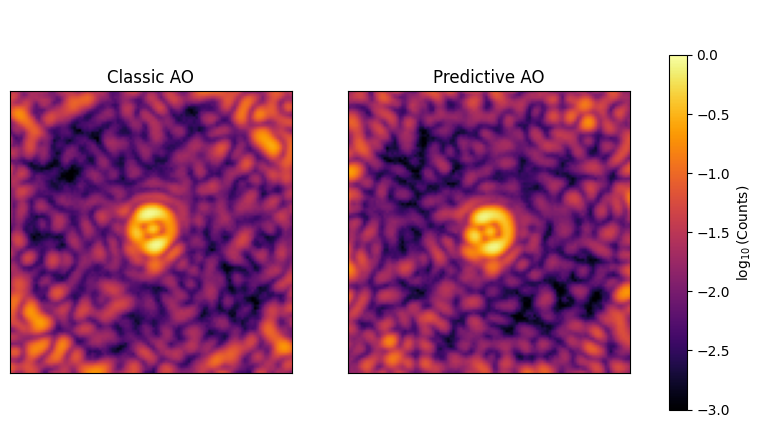

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ------------------------
# Load stacks
# ------------------------
coro_processed_int = np.load(
    "/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy"
)

coro_processed_pred = np.load(
    "/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy"
)

# ------------------------
# Log scaling
# ------------------------
eps = 1e-9

int_log = np.log10(np.maximum(coro_processed_int[:1000, :, :], eps))
pred_log = np.log10(np.maximum(coro_processed_pred[:1000, :, :], eps))

# Shared color limits
vmin = -3
vmax = 0

# ------------------------
# Figure
# ------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

fig.subplots_adjust(top=0.82)

im0 = ax[0].imshow(
    int_log[0],
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

im1 = ax[1].imshow(
    pred_log[0],
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax[0].set_title("Classic AO")
ax[1].set_title("Predictive AO")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

cbar = fig.colorbar(im1, ax=ax)
cbar.set_label(r"$\log_{10}(\mathrm{Counts})$")

title = fig.text(
    0.5, 0.91,
    "Frame 0", 
    ha="center",
    va="top",
    fontsize=16
)

# ------------------------
# Animation
# ------------------------
def update(i):
    im0.set_data(int_log[i])
    im1.set_data(pred_log[i])
    title.set_text(f"Frame {i}")
    return im0, im1, title

ani = FuncAnimation(
    fig,
    update,
    frames=int_log.shape[0],
    interval=30,
    blit=True,
)

ani.save(
    "Check_speckle_change.gif",
    writer=PillowWriter(fps=30)
    )


## Test for one stack

In [ ]:
# GET THE STACKS
ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'

#int
img_file ='/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/int_0.5ro_10ws_coro_2026-07-22T10-45-42.218_0.tif'

coro_not_processed_int = run_pre_processing(img_file = ori_folder + Path(img_file).stem,
                       img_key = 6667, 
                       dark_file = f'{ori_folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{ori_folder}psf', 
                       radius = 55,
                       coords= None
                       )

coro_processed_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy")      # shape: (N, ny, nx)

#pred
img_file ='/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/pred_0.5ro_10ws_coro_2026-07-22T11-40-55.709_0.tif'
coro_not_processed_pred = run_pre_processing(img_file = ori_folder + Path(img_file).stem,
                       img_key = 6667, 
                       dark_file = f'{ori_folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{ori_folder}psf', 
                       radius = 55,
                       coords= None
                       )

coro_processed_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy")      # shape: (N, ny, nx)


ValueError: too many values to unpack (expected 2)

In [ ]:
# GET THE SINGLE FRAMES

DIT_psf = 0.5 #s
DIT_sc_frame = 0.015 #s
factor = DIT_psf / DIT_sc_frame

#perfect psf
unaberrated_PSF = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_uncorrelated.npy")

#coro psf
mean_coro_processed_int = factor * np.mean(coro_processed_int, axis = 0)
mean_coro_not_processed_int = factor * np.mean(coro_not_processed_int, axis = 0)
mean_coro_processed_pred = factor * np.mean(coro_processed_pred, axis = 0)
mean_coro_not_processed_pred = factor * np.mean(coro_not_processed_pred, axis = 0)

#no coro psf
mean_not_processed_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_int_0.5ro_10ws.npy") 
mean_not_processed_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_pred_0.5ro_10ws.npy") 


In [ ]:
def radial_profile(image, binsize=1):
    ny, nx = image.shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2

    y, x = np.indices(image.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    rbin = np.floor(r / binsize).astype(int)

    maxbin = rbin.max() + 1

    profile = np.empty(maxbin)
    std = np.empty(maxbin)
    radius = np.arange(maxbin) * binsize

    for i in range(maxbin):
        mask = rbin == i
        values = image[mask]

        profile[i] = values.mean()
        std[i] = values.std()

    return radius, profile, std

In [ ]:
def plot_raw_contrast(unaberrated_PSF,
                      mean_psfs,
                      mean_psfs_coro,
                      binsize):

    #rad_to_arcsec = 206265

    # Normalize everything by the same peak
    peak = unaberrated_PSF.max()
    r0, y_unaber, _ = radial_profile(unaberrated_PSF / peak, binsize)


    #plt.figure(figsize=(6,4))
    colors = ['orangered', 'yellowgreen', 'blue']

    # plt.plot(r0,
    #         y_unaber,
    #         color='k',
    #         label='Unaberrated')
    
    for (i, (mean_psf_stat, mean_psf_stat_coro)) in enumerate(zip(mean_psfs, mean_psfs_coro)):
        _, y_noncoro, _ = radial_profile(mean_psf_stat / peak, binsize)
        _, y_coro, yerr = radial_profile(mean_psf_stat_coro / peak, binsize)

        strehl = mean_psf_stat.max() / peak
        r = np.float64(r0) / calculate_fwhm(mean_psf_stat)

        label               = 'Classic AO' if i==0 else 'Predicitve AO' 

        if i ==0:
            plt.plot(r,
                    y_unaber,
                    color='k',
                    label='Unaberrated')
            plt.plot(r, y_noncoro, '--',  label='Non-coronagraphic', color = 'black', lw = 2)
            plt.plot(r, y_coro,':', label='Coronagraphic', color = 'black', lw = 2)      
        plt.plot(r, y_noncoro, '--', color = colors[i], lw = 2)
        plt.plot(r, y_coro, ':', color = colors[i], lw = 2)
        plt.scatter(0, 0, marker = 'o', color = colors[i], label = (label + f' Strehl = {float(strehl):.2f}'))

    plt.yscale('log')
    plt.xlim(left =0)
    plt.ylim(3e-6, 1)

    plt.xlabel("Angular separation [FWHM]")
    plt.ylabel("Raw contrast")

    plt.legend()
    plt.tight_layout()
    



FWHM_x = 4.80 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.82 pix 

FWHM_x = 4.83 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.81 pix 



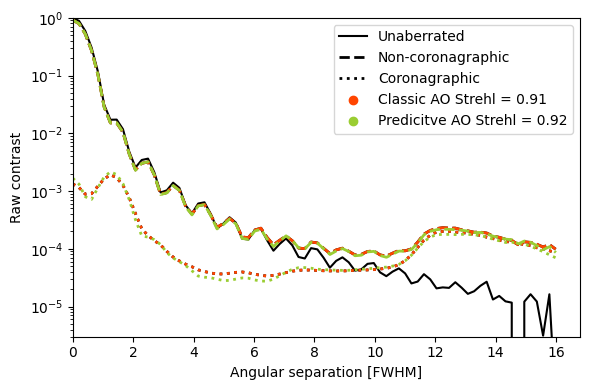

In [ ]:
plt.figure(figsize=(6,4))
plot_raw_contrast(unaberrated_PSF,
                      [mean_not_processed_int, mean_not_processed_pred],
                      [mean_coro_processed_int,mean_coro_processed_pred ],
                      1)


FWHM_x = 4.80 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.82 pix 

FWHM_x = 4.83 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.81 pix 



/tmp/ipykernel_3597140/71752069.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3597140/3628131194.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


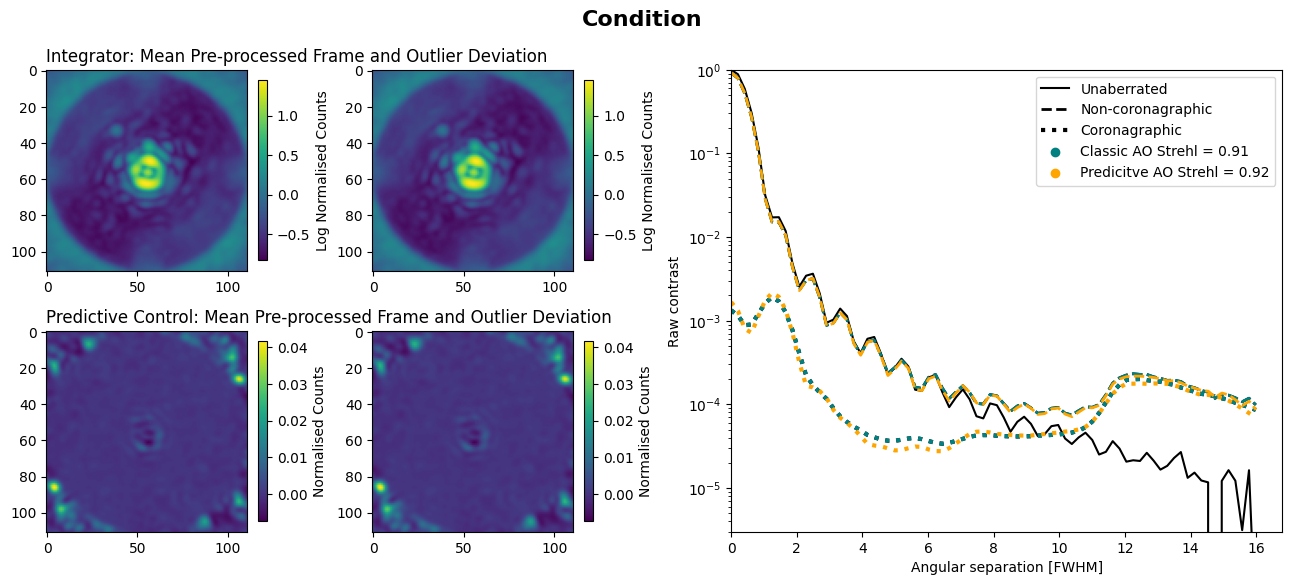

In [56]:
#unaberrated_PSF = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_uncorrelated.npy")
fig = plt.figure(figsize = (16,6))
# Main grid: left column narrow, right column wide
gs = fig.add_gridspec(1, 2, width_ratios=[1,1], wspace=0.25)

gs_left = gs[0].subgridspec(2, 2, wspace=0.45, hspace = 0.3)

ax1 = fig.add_subplot(gs_left[0])
ax2 = fig.add_subplot(gs_left[1])
ax3 = fig.add_subplot(gs_left[2])
ax4 = fig.add_subplot(gs_left[3])

# Right image spans the entire right column
ax_big = fig.add_subplot(gs[1])

ax1.set_title('Integrator: Mean Pre-processed Frame and Outlier Deviation', loc = 'left')
im = ax1.imshow(np.log10(mean_coro_processed_int))
plt.colorbar(im, label='Log Normalised Counts', fraction =0.04)

ax2.set_title(' ')
im = ax2.imshow(np.log10(mean_coro_processed_int))
plt.colorbar(im, label='Log Normalised Counts', fraction =0.04)

#plt.subplot(1,3,3)
ax_big.set_title(' ')
plot_raw_contrast(unaberrated_PSF,
                      [mean_not_processed_int, mean_not_processed_pred],
                      [mean_coro_processed_int,mean_coro_processed_pred ],
                      1)

#plt.subplot(1,3,2)
ax3.set_title('Predictive Control: Mean Pre-processed Frame and Outlier Deviation', loc = 'left')
im = ax3.imshow((mean_coro_not_processed_int - mean_coro_processed_int))
plt.colorbar(im, label='Normalised Counts', fraction =0.04)

ax4.set_title(' ')
im = ax4.imshow((mean_coro_not_processed_int - mean_coro_processed_int))
plt.colorbar(im, label='Normalised Counts', fraction =0.04)

plt.suptitle('Condition', fontweight = 'bold', fontsize = 16)
plt.tight_layout()

## For all stacks

In [2]:
def radial_profile(image, binsize=1):
    ny, nx = image.shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2

    y, x = np.indices(image.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    rbin = np.floor(r / binsize).astype(int)

    maxbin = rbin.max() + 1

    profile = np.empty(maxbin)
    std = np.empty(maxbin)
    radius = np.arange(maxbin) * binsize

    for i in range(maxbin):
        mask = rbin == i
        values = image[mask]

        profile[i] = values.mean()
        std[i] = values.std()

    return radius, profile, std

In [3]:
def plot_raw_contrast(unaberrated_PSF,
                      mean_psfs,
                      mean_psfs_coro,
                      binsize):

    #rad_to_arcsec = 206265

    # Normalize everything by the same peak
    peak = unaberrated_PSF.max()
    r0, y_unaber, _ = radial_profile(unaberrated_PSF / peak, binsize)


    #plt.figure(figsize=(6,4))
    colors = ['orangered', 'yellowgreen', 'blue']

    # plt.plot(r0,
    #         y_unaber,
    #         color='k',
    #         label='Unaberrated')
    
    for (i, (mean_psf_stat, mean_psf_stat_coro)) in enumerate(zip(mean_psfs, mean_psfs_coro)):
        _, y_noncoro, _ = radial_profile(mean_psf_stat / peak, binsize)
        _, y_coro, yerr = radial_profile(mean_psf_stat_coro / peak, binsize)

        strehl = mean_psf_stat.max() / peak
        r = np.float64(r0) / calculate_fwhm(mean_psf_stat)

        label               = 'Classic AO' if i==0 else 'Predicitve AO' 

        if i ==0:
            plt.plot(r,
                    y_unaber,
                    color='k',
                    label='Unaberrated')
            plt.plot(r, y_noncoro, '--',  label='Non-coronagraphic', color = 'black', lw = 2)
            plt.plot(r, y_coro,':', label='Coronagraphic', color = 'black', lw = 2)      
        plt.plot(r, y_noncoro, '--', color = colors[i], lw = 2)
        plt.plot(r, y_coro, ':', color = colors[i], lw = 2)
        plt.scatter(0, 0, marker = 'o', color = colors[i], label = (label + f' Strehl = {float(strehl):.2f}'))

    plt.yscale('log')
    plt.xlim(left =0)
    plt.ylim(3e-6, 1)

    plt.xlabel("Angular separation [FWHM]")
    plt.ylabel("Raw contrast")

    plt.legend()
    plt.tight_layout()
    

Text(0.5, 1.0, 'Pre-processed Unaberrated PSF')

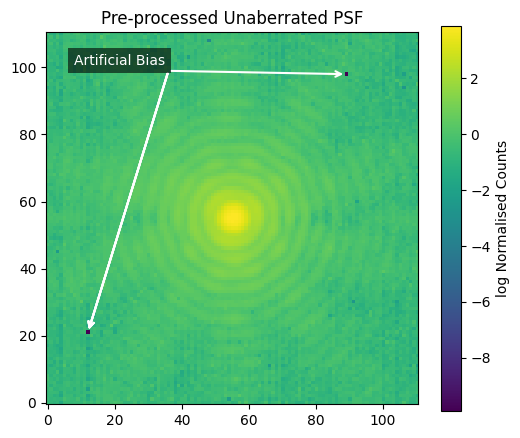

In [35]:
plt.figure(figsize=(6, 5))
plt.imshow(np.log10(unaberrated_PSF), origin="lower")
plt.colorbar(label="log Normalised Counts")

# Find clipped pixels
mask = unaberrated_PSF < 5e-8
y, x = np.where(mask)

# Fixed location of the text box
text_x = 35
text_y = 100


# Draw arrows to a few representative pixels
indices = np.linspace(0, len(x) - 1, 5, dtype=int)

for i in indices:
    plt.annotate(
        "",
        xy=(x[i], y[i]),          # clipped pixel
        xytext=(text_x +1 , text_y -1),  # text box
        arrowprops=dict(
            arrowstyle="->",
            color="white",
            lw=1.5,
        ),
    )

plt.text(
    text_x,
    text_y,
    "Artificial Bias", #\n(clipped to $10^{-9}$)",
    color="white",
    fontsize=10,
    ha="right",
    va="bottom",
    bbox=dict(facecolor="black", alpha=0.6, edgecolor="none")
)
plt.title('Pre-processed Unaberrated PSF')


FWHM_x = 4.80 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.82 pix 

FWHM_x = 4.83 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.81 pix 



/tmp/ipykernel_601632/3845605196.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_601632/2145609304.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


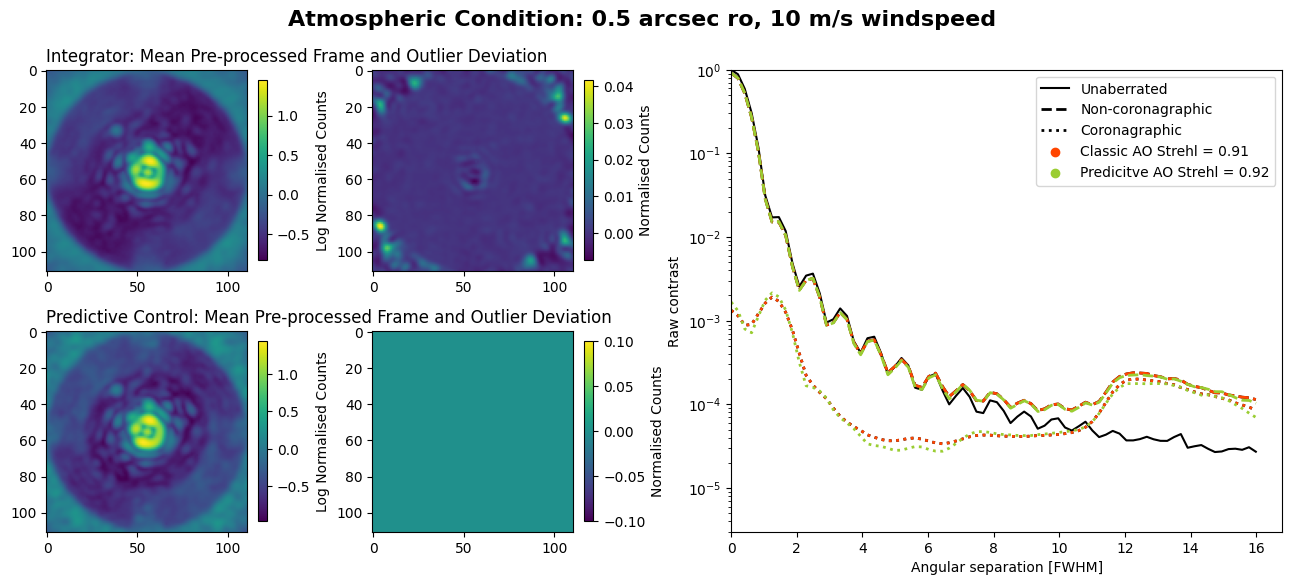

FWHM_x = 4.79 pix
FWHM_y = 4.82 pix
Mean FWHM = 4.81 pix 

FWHM_x = 4.79 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.81 pix 



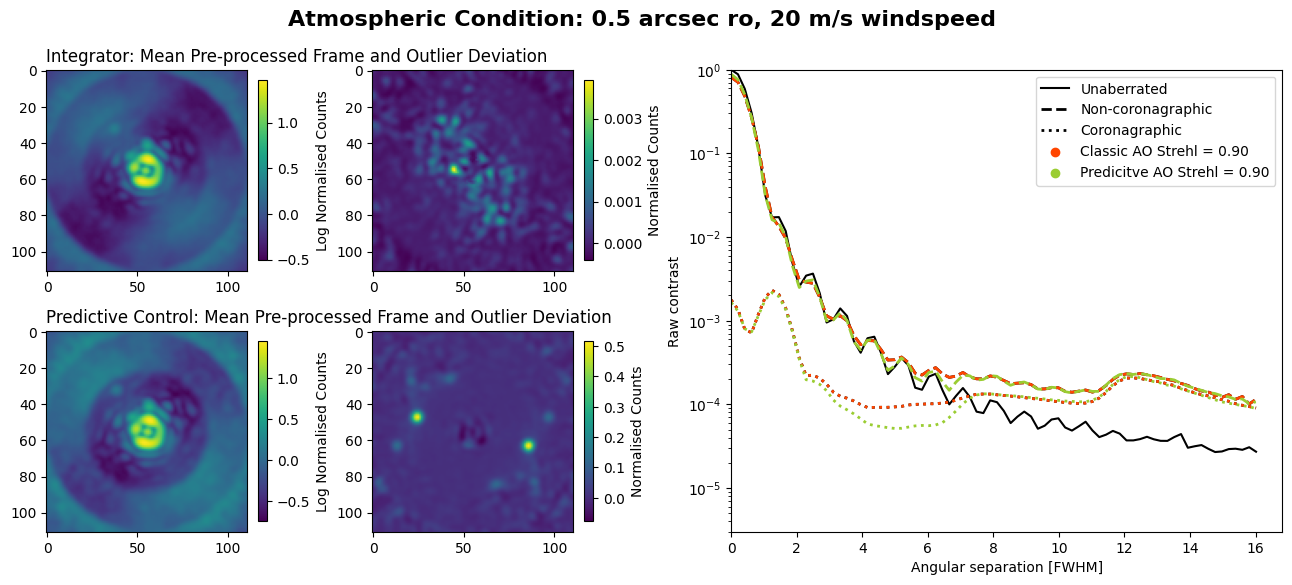

FWHM_x = 4.78 pix
FWHM_y = 4.81 pix
Mean FWHM = 4.79 pix 

FWHM_x = 4.78 pix
FWHM_y = 4.81 pix
Mean FWHM = 4.79 pix 



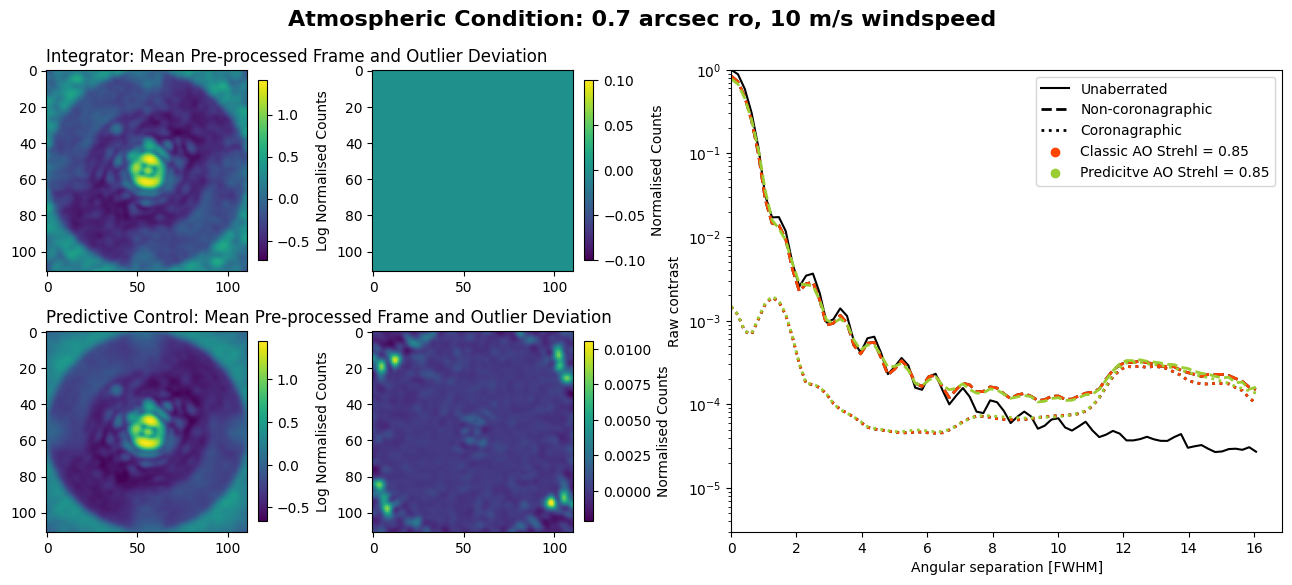

FWHM_x = 4.77 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.79 pix 

FWHM_x = 4.77 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.79 pix 



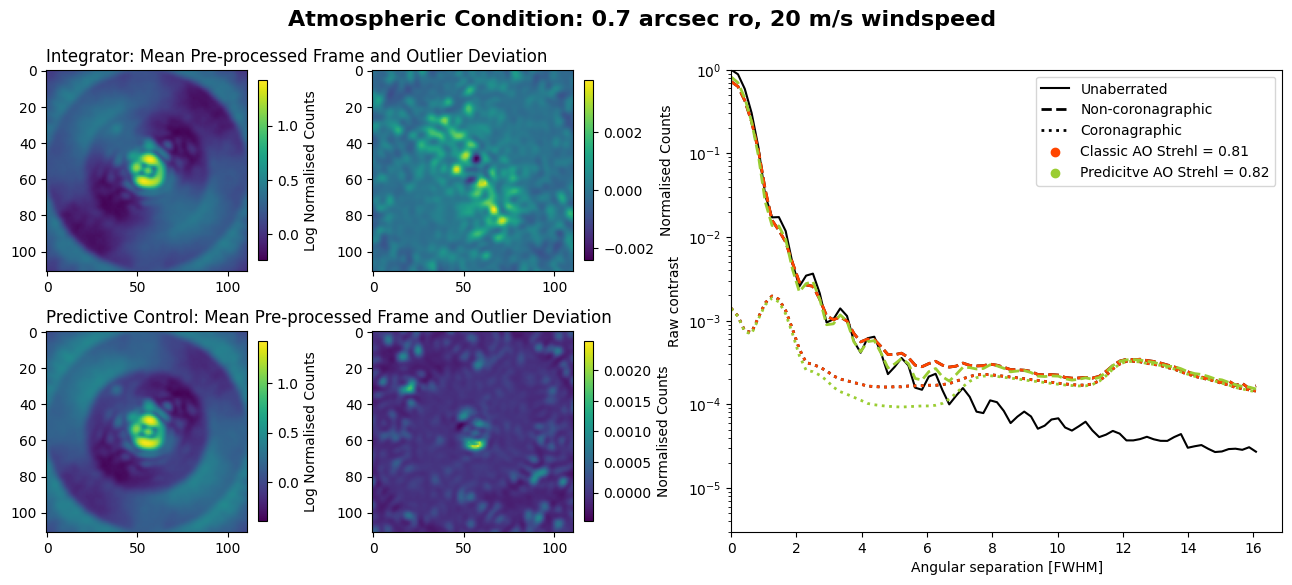

FWHM_x = 4.78 pix
FWHM_y = 4.75 pix
Mean FWHM = 4.76 pix 

FWHM_x = 4.76 pix
FWHM_y = 4.79 pix
Mean FWHM = 4.77 pix 



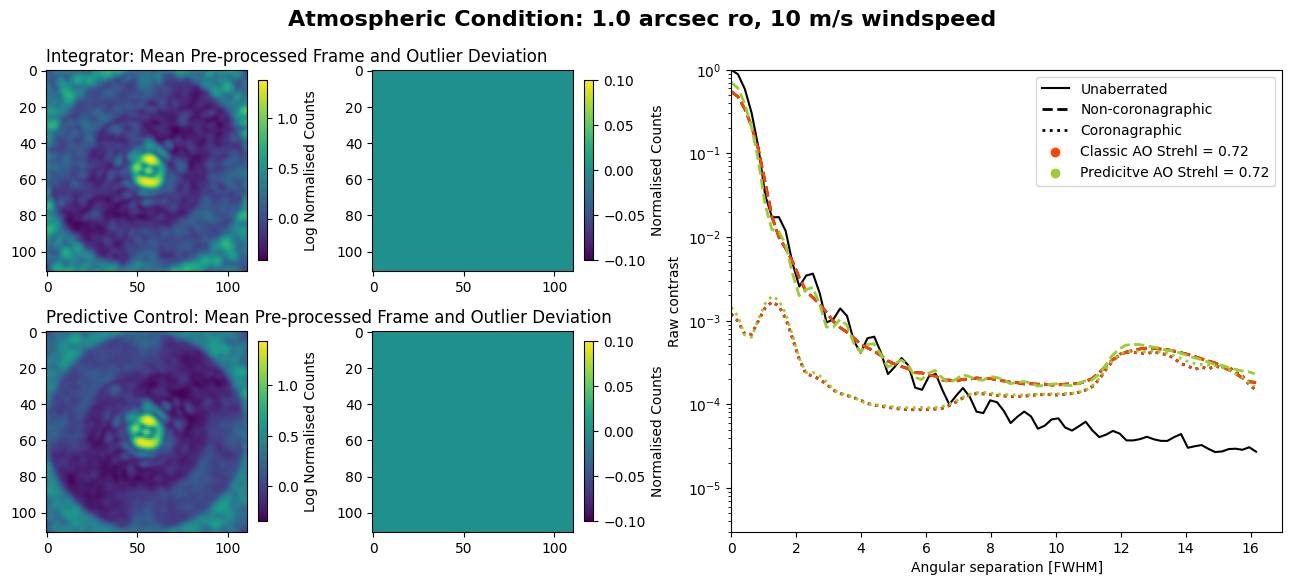

FWHM_x = 4.77 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.78 pix 

FWHM_x = 4.76 pix
FWHM_y = 4.78 pix
Mean FWHM = 4.77 pix 



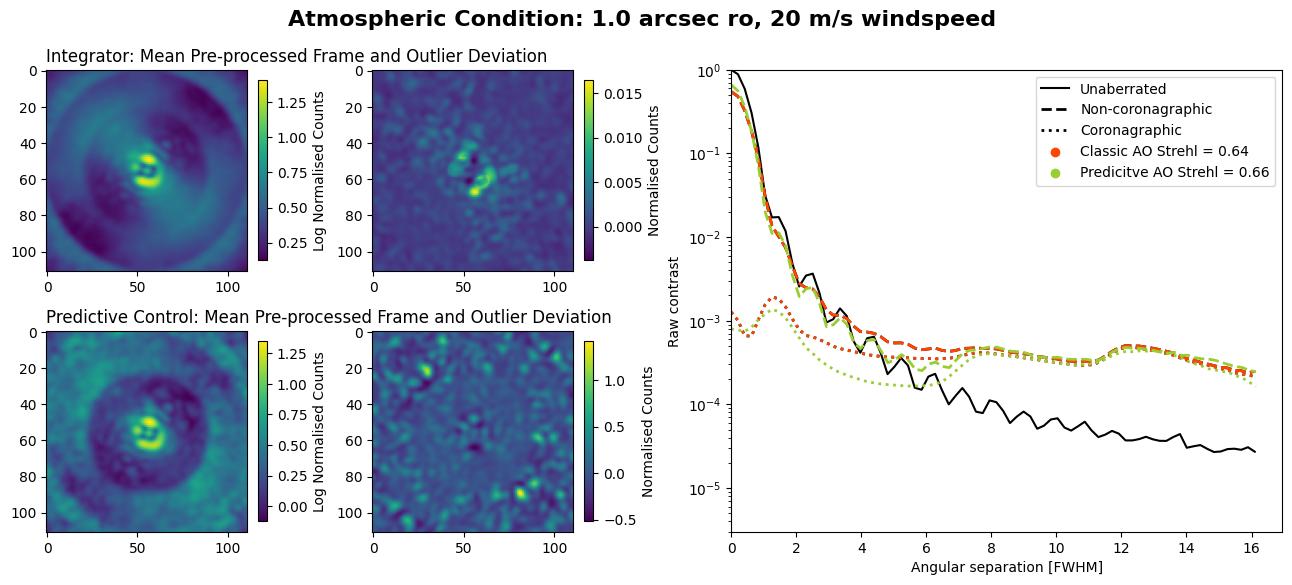

In [ ]:
DIT_psf = 0.5 #s
DIT_sc_frame = 0.015 #s
factor = DIT_psf / DIT_sc_frame
ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'


#perfect psf
unaberrated_PSF = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_uncorrelated.npy")


for ro in [0.5,0.7,1.0]:
    for ws in [10, 20]:
        means_coro_not_processed = []
        means_coro_processed = []
        means_not_processed = []
        for algo_name in ['int', 'pred']:
            #coro frames with outliers
            coro_not_processed = run_pre_processing(img_file = ori_folder + f'{algo_name}_{ro}ro_{ws}ws_coro',
                                img_key = 6667, 
                                dark_file = f'{ori_folder}darks_img',  
                                dark_key= 10000, 
                                ref_psf=f'{ori_folder}psf', 
                                radius = 55,
                                coords= None)
            means_coro_not_processed.append( factor * np.mean(coro_not_processed, axis = 0))

            #pre-processed coro frames
            coro_processed = np.load(f"/home/aosimul/noah/data/ghost_images/10_20ws/{algo_name}_{ro}ro_{ws}ws.npy")      # shape: (N, ny, nx)
            means_coro_processed.append(factor * np.mean(coro_processed, axis = 0))

            #no coro psf
            means_not_processed.append(np.load(f"/home/aosimul/noah/data/ghost_images/10_20ws/psf_{algo_name}_{ro}ro_{ws}ws.npy") )


        fig = plt.figure(figsize = (16,6))

        # Main grid: left column narrow, right column wide
        gs = fig.add_gridspec(1, 2, width_ratios=[1,1], wspace=0.25)

        gs_left = gs[0].subgridspec(2, 2, wspace=0.45, hspace = 0.3)

        ax1 = fig.add_subplot(gs_left[0])
        ax2 = fig.add_subplot(gs_left[1])
        ax3 = fig.add_subplot(gs_left[2])
        ax4 = fig.add_subplot(gs_left[3])

        # Right image spans the entire right column
        ax_big = fig.add_subplot(gs[1])

        ax1.set_title('Integrator: Mean Pre-processed Frame and Outlier Deviation', loc = 'left')
        im = ax1.imshow(np.log10(means_coro_processed[0]))
        plt.colorbar(im, label='Log Normalised Counts', fraction =0.04)

        ax2.set_title(' ')
        im = ax2.imshow((means_coro_not_processed[0] - means_coro_processed[0]))
        plt.colorbar(im, label='Normalised Counts', fraction =0.04)

        #plt.subplot(1,3,3)
        ax_big.set_title(' ')
        plot_raw_contrast(unaberrated_PSF,
                            means_not_processed,
                            means_coro_processed,
                            1)

        #plt.subplot(1,3,2)
        ax3.set_title('Predictive Control: Mean Pre-processed Frame and Outlier Deviation', loc = 'left')
        im = ax3.imshow(np.log10(means_coro_processed[1]))
        plt.colorbar(im, label='Log Normalised Counts', fraction =0.04)

        ax4.set_title(' ')
        im = ax4.imshow((means_coro_not_processed[1] - means_coro_processed[1]))
        plt.colorbar(im, label='Normalised Counts', fraction =0.04)

        plt.suptitle(f'Atmospheric Condition: {ro} arcsec ro, {ws} m/s windspeed', fontweight = 'bold', fontsize = 16)
        plt.tight_layout()
        plt.show()


# Load the residuals into gifs

In [7]:
from astropy.io import fits
from pathlib import Path
import numpy as np

dir = Path('/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/coro_5r0_10windspeed_int/residuals/_PCA_020_components')
files = sorted(dir.glob("*.fits"))

stack = np.stack([fits.getdata(f) for f in files])

print(f"Shape   : {stack.shape}")
print(f"Mean    : {stack.mean():.3e}")
print(f"Median  : {np.median(stack):.3e}")
print(f"Std     : {stack.std():.3e}")
print(f"Min     : {stack.min():.3e}")
print(f"Max     : {stack.max():.3e}")

v = np.abs(stack).max()
print(f"Symmetric limits: {-v:.3e} to {v:.3e}")

Shape   : (881, 111, 111)
Mean    : 7.487e-06
Median  : -1.456e-06
Std     : 6.705e-04
Min     : -2.245e-02
Max     : 4.632e-02
Symmetric limits: -4.632e-02 to 4.632e-02


In [13]:
folder = '/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/'
components              = [10]

name = 'coro_0.5r0_10windspeed_int'
create_pca_gif(
    folder + name,
    components,
    output_gif=f"/home/aosimul/noah/results/animations/pca_anim/pca_{name}.gif",
    duration=0.5)

Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_0.5r0_10windspeed_int.gif_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_0.5r0_10windspeed_int.gif_CADI.gif


In [36]:
folder = '/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/'
components              = np.concatenate(
        [
            np.arange(0, 10, 1)[1:],
            np.arange(10, 50, 5),
            np.arange(50, 150, 15),
        ]
    )
#path = '/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/coro_0.5r0_10windspeed_int/residuals/_PCA_001_components'
components = [1, 10, 100]
for ro in [0.5,0.7,1.0]:
    for ws in [10, 20]:
        for algo_name in ['int', 'pred']:
            name = f"coro_{int(ro*10)}r0_{ws}windspeed_{algo_name}"

            create_pca_gif(
                folder + name,
                components,
                output_gif=f"/home/aosimul/noah/results/animations/pca_anim/pca_{name}",
                duration=0.5)

Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_10windspeed_int_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_10windspeed_int_CADI.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_10windspeed_pred_PCAD.gif


Exception ignored in: <function PluginV3.__del__ at 0x7f6665d6f9c0>
Traceback (most recent call last):
  File "/home/aosimul/noah/env_hci/lib/python3.12/site-packages/imageio/core/v3_plugin_api.py", line 370, in __del__
    self.close()
  File "/home/aosimul/noah/env_hci/lib/python3.12/site-packages/imageio/plugins/pillow.py", line 145, in close
    self._flush_writer()
  File "/home/aosimul/noah/env_hci/lib/python3.12/site-packages/imageio/plugins/pillow.py", line 486, in _flush_writer
    primary_image.save(self._request.get_file(), **self.save_args)
  File "/home/aosimul/noah/env_hci/lib/python3.12/site-packages/PIL/Image.py", line 2671, in save
    raise ValueError(msg) from e
ValueError: unknown file extension: 


Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_10windspeed_pred_CADI.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_20windspeed_int_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_20windspeed_int_CADI.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_20windspeed_pred_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_5r0_20windspeed_pred_CADI.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_7r0_10windspeed_int_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_7r0_10windspeed_int_CADI.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_7r0_10windspeed_pred_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_7r0_10windspeed_pred_CADI.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_anim/pca_coro_7r0_20windspeed_int_PCAD.gif
Saved GIF: /home/aosimul/noah/resul